# Sentiment Analysis

In [3]:
!pip install pandas numpy scikit-learn imbalanced-learn matplotlib seaborn sympy
!pip3 uninstall --yes torch torchaudio torchvision torchtext torchdata
!pip3 install torch torchaudio torchvision torchtext torchdata
!pip install transformers

import pandas as pd
import numpy as np
import torch
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
from transformers import pipeline
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

Found existing installation: torch 2.11.0
Uninstalling torch-2.11.0:
  Successfully uninstalled torch-2.11.0
Found existing installation: torchaudio 2.11.0
Uninstalling torchaudio-2.11.0:
  Successfully uninstalled torchaudio-2.11.0
Found existing installation: torchvision 0.26.0
Uninstalling torchvision-0.26.0:
  Successfully uninstalled torchvision-0.26.0
Found existing installation: torchtext 0.18.0
Uninstalling torchtext-0.18.0:
  Successfully uninstalled torchtext-0.18.0
Found existing installation: torchdata 0.11.0
Uninstalling torchdata-0.11.0:
  Successfully uninstalled torchdata-0.11.0
  Using cached torch-2.11.0-cp312-cp312-manylinux_2_28_x86_64.whl.metadata (29 kB)
  Using cached torchaudio-2.11.0-cp312-cp312-manylinux_2_28_x86_64.whl.metadata (6.9 kB)
  Using cached torchvision-0.26.0-cp312-cp312-manylinux_2_28_x86_64.whl.metadata (5.5 kB)
  Using cached torchtext-0.18.0-cp312-cp312-manylinux1_x86_64.whl.metadata (7.9 kB)
  Using cached torchdata-0.11.0-py3-none-any.whl.met

In [4]:
PREPROCESSED_FILE = "kfc_preprocessed_sentiment.csv"
LABELLED_SAMPLE   = "kfc_10_percent_labelled.csv"
OUTPUT_FILE       = "kfc_sentiment_labelled_full.csv"
CHART_FILE        = "sentiment_distribution.png"

## Generate 10% Labelled Sample
Run once, then manually label the `Manual_Label` column in the CSV.

In [5]:
#10% sample files
df_temp = pd.read_csv(PREPROCESSED_FILE)
sample = df_temp.sample(frac=0.10, random_state=42)
sample["Manual_Label"] = ""
sample.to_csv(LABELLED_SAMPLE, index=False)
print(f"Sample saved: {LABELLED_SAMPLE} ({len(sample)} comments)")

Sample saved: kfc_10_percent_labelled.csv (1892 comments)


## Load Datasets

In [6]:
#load dataset
df_full = pd.read_csv(PREPROCESSED_FILE)
print(f"Full dataset: {len(df_full)} comments")

#manual labeled 10% files before
df_labelled = pd.read_csv(LABELLED_SAMPLE)
print(f"Labelled sample: {len(df_labelled)} comments")
print(df_labelled["Manual_Label"].value_counts())

Full dataset: 18920 comments
Labelled sample: 1892 comments
Manual_Label
Neutral     1187
Negative     384
Positive     321
Name: count, dtype: int64


In [8]:
#train/test 80/20
X = df_labelled["Tokenised_Comment"]
y = df_labelled["Manual_Label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(f"Train: {len(X_train)} | Test: {len(X_test)}")

Train: 1513 | Test: 379


In [9]:
#Vectorisation and SMOTE
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_bow = vectorizer.fit_transform(X_train)
X_test_bow = vectorizer.transform(X_test)

smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_bow, y_train)
print("After SMOTE:")
print(pd.Series(y_train_balanced).value_counts())

After SMOTE:
Manual_Label
Neutral     949
Negative    949
Positive    949
Name: count, dtype: int64


In [10]:
#Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_balanced, y_train_balanced)
lr_preds = lr_model.predict(X_test_bow)
lr_accuracy = accuracy_score(y_test, lr_preds)

print(f"Logistic Regression Accuracy: {lr_accuracy:.3f}")
print(classification_report(y_test, lr_preds))

Logistic Regression Accuracy: 0.770
              precision    recall  f1-score   support

    Negative       0.61      0.74      0.67        77
     Neutral       0.84      0.82      0.83       238
    Positive       0.75      0.61      0.67        64

    accuracy                           0.77       379
   macro avg       0.73      0.72      0.72       379
weighted avg       0.78      0.77      0.77       379



In [11]:
# Naive Bayes
nb_model = MultinomialNB()
nb_model.fit(X_train_balanced, y_train_balanced)
nb_preds = nb_model.predict(X_test_bow)
nb_accuracy = accuracy_score(y_test, nb_preds)

print(f"Naive Bayes Accuracy: {nb_accuracy:.3f}")
print(classification_report(y_test, nb_preds))

Naive Bayes Accuracy: 0.512
              precision    recall  f1-score   support

    Negative       0.37      0.81      0.51        77
     Neutral       0.86      0.37      0.52       238
    Positive       0.39      0.67      0.50        64

    accuracy                           0.51       379
   macro avg       0.54      0.62      0.51       379
weighted avg       0.68      0.51      0.51       379



In [13]:
#RoBERTa
def map_label(label_str):
    l = label_str.lower()
    if "neg" in l or "label_0" in l: return "Negative"
    elif "pos" in l or "label_2" in l: return "Positive"
    else: return "Neutral"

roberta = pipeline(
    "sentiment-analysis",
    model="cardiffnlp/twitter-roberta-base-sentiment-latest",
    tokenizer="cardiffnlp/twitter-roberta-base-sentiment-latest",
    max_length=512, truncation=True,
)

roberta_preds = [map_label(roberta(str(t)[:512])[0]["label"]) for t in X_test]
roberta_accuracy = accuracy_score(y_test, roberta_preds)

print(f"RoBERTa Accuracy: {roberta_accuracy:.3f}")
print(classification_report(y_test, roberta_preds))

pytorch_model.bin:   0%|          | 0.00/501M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/501M [00:00<?, ?B/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 
roberta.pooler.dense.bias       | UNEXPECTED |  | 
roberta.pooler.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

RoBERTa Accuracy: 0.665
              precision    recall  f1-score   support

    Negative       0.49      0.73      0.59        77
     Neutral       0.78      0.73      0.75       238
    Positive       0.54      0.34      0.42        64

    accuracy                           0.66       379
   macro avg       0.60      0.60      0.59       379
weighted avg       0.68      0.66      0.66       379



In [14]:
#BERTweet
bertweet = pipeline(
    "sentiment-analysis",
    model="finiteautomata/bertweet-base-sentiment-analysis",
    tokenizer="finiteautomata/bertweet-base-sentiment-analysis",
    max_length=128, truncation=True,
)

bertweet_preds = [map_label(bertweet(str(t)[:128])[0]["label"]) for t in X_test]
bertweet_accuracy = accuracy_score(y_test, bertweet_preds)

print(f"BERTweet Accuracy: {bertweet_accuracy:.3f}")
print(classification_report(y_test, bertweet_preds))

config.json:   0%|          | 0.00/949 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/540M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/540M [00:00<?, ?B/s]

RobertaForSequenceClassification LOAD REPORT from: finiteautomata/bertweet-base-sentiment-analysis
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

special_tokens_map.json:   0%|          | 0.00/167 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

bpe.codes: 0.00B [00:00, ?B/s]

emoji is not installed, thus not converting emoticons or emojis into text. Install emoji: pip3 install emoji==0.6.0


BERTweet Accuracy: 0.689
              precision    recall  f1-score   support

    Negative       0.54      0.75      0.63        77
     Neutral       0.77      0.77      0.77       238
    Positive       0.58      0.30      0.39        64

    accuracy                           0.69       379
   macro avg       0.63      0.61      0.60       379
weighted avg       0.69      0.69      0.68       379



In [15]:
#Comparison
results = {
    "Logistic Regression": lr_accuracy,
    "Naive Bayes": nb_accuracy,
    "RoBERTa": roberta_accuracy,
    "BERTweet": bertweet_accuracy,
}

print("MODEL COMPARISON")
print("=" * 40)
for name, acc in sorted(results.items(), key=lambda x: x[1], reverse=True):
    marker = " <-- BEST" if acc == max(results.values()) else ""
    print(f"  {name:25s}  {acc:.3f}{marker}")

MODEL COMPARISON
  Logistic Regression        0.770 <-- BEST
  BERTweet                   0.689
  RoBERTa                    0.665
  Naive Bayes                0.512


In [16]:
#labeled full dataset
X_all_bow = vectorizer.transform(df_full["Tokenised_Comment"])
df_full["Sentiment"] = lr_model.predict(X_all_bow)

print(f"Labelled {len(df_full)} comments.")
print(df_full["Sentiment"].value_counts())

Labelled 18920 comments.
Sentiment
Neutral     12236
Negative     4113
Positive     2571
Name: count, dtype: int64


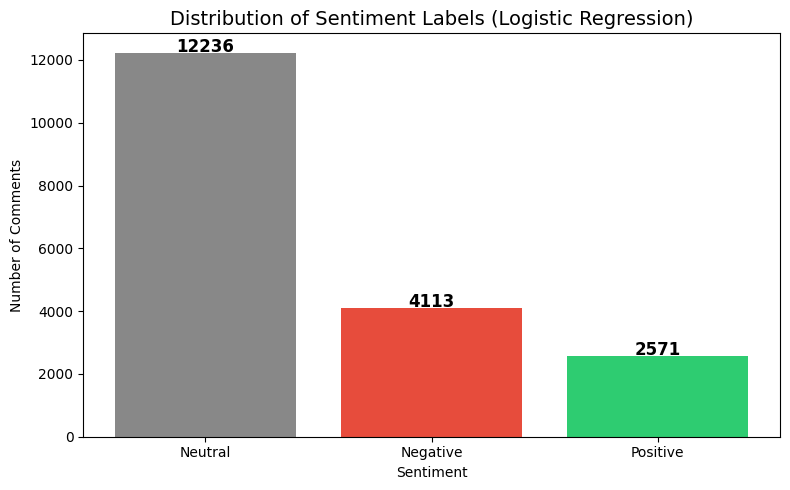

In [17]:
#sentiment
counts = df_full["Sentiment"].value_counts()
colors = {"Neutral": "#888888", "Negative": "#E74C3C", "Positive": "#2ECC71"}

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(counts.index, counts.values,
              color=[colors.get(c, "#3498DB") for c in counts.index])
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            str(val), ha="center", fontsize=12, fontweight="bold")

ax.set_title("Distribution of Sentiment Labels (Logistic Regression)", fontsize=14)
ax.set_xlabel("Sentiment")
ax.set_ylabel("Number of Comments")
plt.tight_layout()
plt.savefig(CHART_FILE, dpi=150)
plt.show()

In [18]:
df_full.to_csv(OUTPUT_FILE, index=False, encoding="utf-8-sig")
print(f"Saved to: {OUTPUT_FILE}")
print(df_full["Sentiment"].value_counts())

Saved to: kfc_sentiment_labelled_full.csv
Sentiment
Neutral     12236
Negative     4113
Positive     2571
Name: count, dtype: int64
